<a href="https://colab.research.google.com/github/Raihanbujeee/PCVK_Ganjil_2026/blob/main/Modul_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

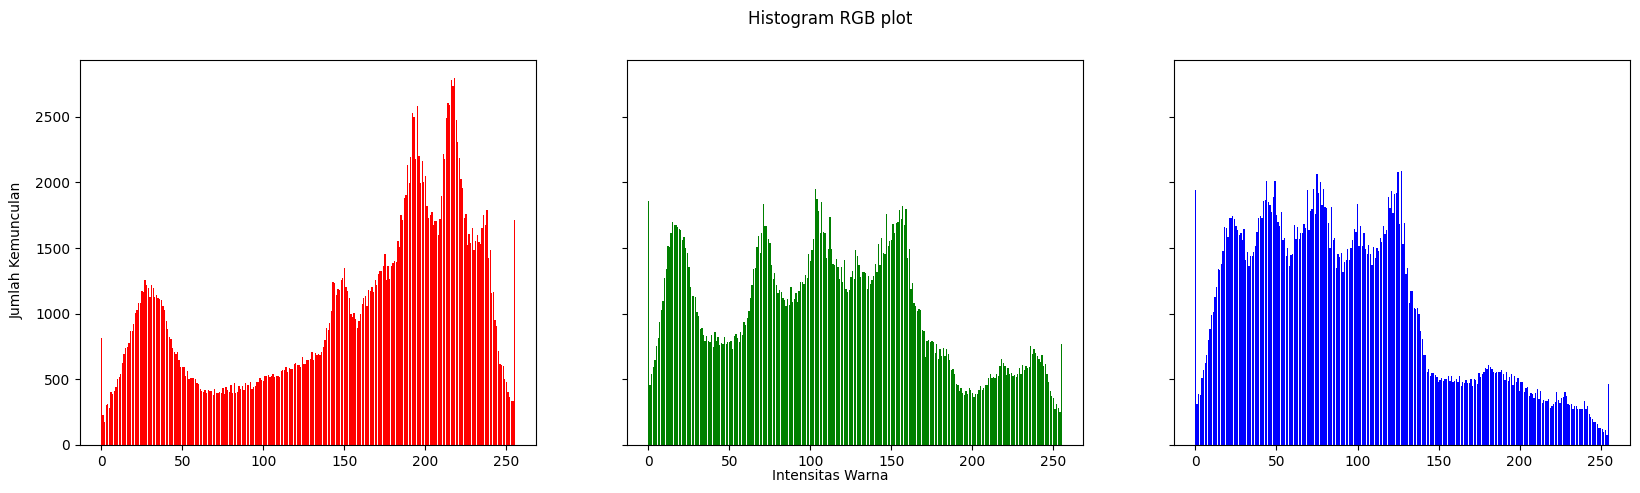

In [3]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/lena.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


path_lena = '/content/drive/MyDrive/PCVK/GAMBAR/lena.jpeg'
img = cv.imread(path_lena)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

channel_merah = img[:,:,0]

# --- A. CARA MANUAL ---
hist_manual = np.zeros(256)
for y in range(0, height):
    for x in range(0, width):
        hist_manual[img[y][x][0]] += 1

# --- B. CARA NUMPY ---
hist_np, _ = np.histogram(channel_merah, bins=256, range=(0,256))

# --- C. CARA OPENCV ---
# Ingat, calcHist butuh input dalam bentuk list
hist_cv = cv.calcHist([img], [0], None, [256], [0,256]).flatten()

# --- PEMBUKTIAN SELISIH MAKSIMUM ---
selisih_np_manual = np.max(np.abs(hist_np - hist_manual))
selisih_cv_manual = np.max(np.abs(hist_cv - hist_manual))

print("=== HASIL PEMBUKTIAN SELISIH ===")
print(f"Selisih maksimum NumPy vs Manual  : {selisih_np_manual}")
print(f"Selisih maksimum OpenCV vs Manual : {selisih_cv_manual}")

=== HASIL PEMBUKTIAN SELISIH ===
Selisih maksimum NumPy vs Manual  : 0.0
Selisih maksimum OpenCV vs Manual : 0.0


In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


path_lena = '/content/drive/MyDrive/PCVK/GAMBAR/KTM_LAMA.png'
img = cv.imread(path_lena)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

channel_merah = img[:,:,0]

# --- A. CARA MANUAL ---
hist_manual = np.zeros(256)
for y in range(0, height):
    for x in range(0, width):
        hist_manual[img[y][x][0]] += 1

# --- B. CARA NUMPY ---
hist_np, _ = np.histogram(channel_merah, bins=256, range=(0,256))

# --- C. CARA OPENCV ---
# Ingat, calcHist butuh input dalam bentuk list
hist_cv = cv.calcHist([img], [0], None, [256], [0,256]).flatten()

# --- PEMBUKTIAN SELISIH MAKSIMUM ---
selisih_np_manual = np.max(np.abs(hist_np - hist_manual))
selisih_cv_manual = np.max(np.abs(hist_cv - hist_manual))

print("=== HASIL PEMBUKTIAN SELISIH ===")
print(f"Selisih maksimum NumPy vs Manual  : {selisih_np_manual}")
print(f"Selisih maksimum OpenCV vs Manual : {selisih_cv_manual}")

=== HASIL PEMBUKTIAN SELISIH ===
Selisih maksimum NumPy vs Manual  : 0.0
Selisih maksimum OpenCV vs Manual : 0.0


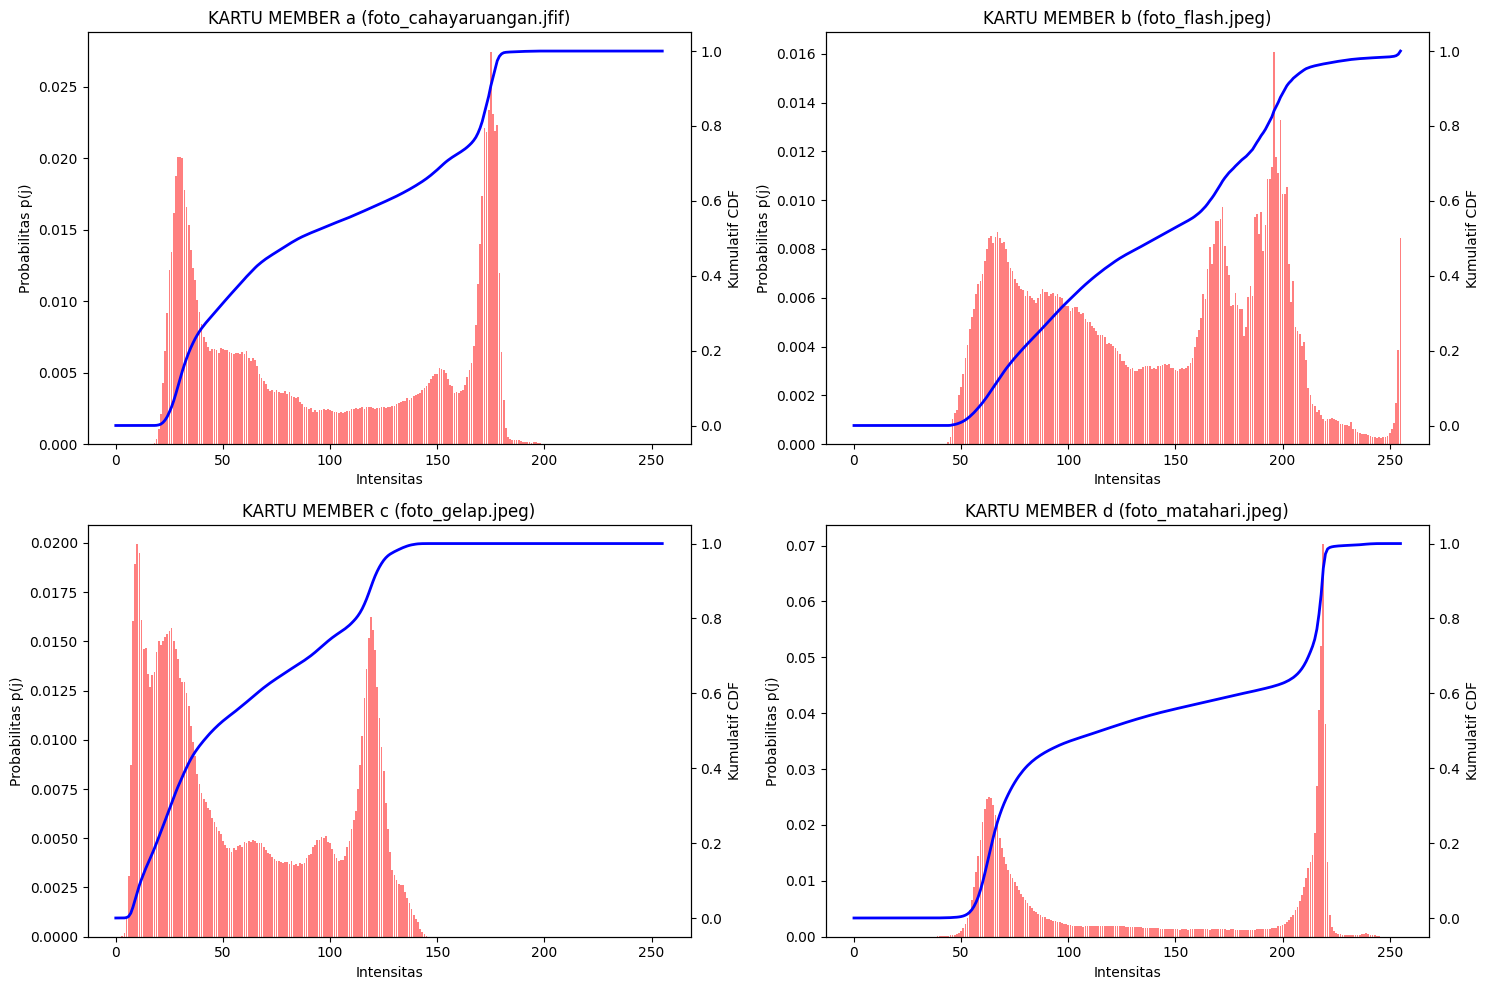

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


paths = [
    '/content/drive/MyDrive/PCVK/GAMBAR/foto_cahayaruangan.jfif',
    '/content/drive/MyDrive/PCVK/GAMBAR/foto_flash.jpeg',
    '/content/drive/MyDrive/PCVK/GAMBAR/foto_gelap.jpeg',
    '/content/drive/MyDrive/PCVK/GAMBAR/foto_matahari.jpeg'
]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.ravel()

for i, path in enumerate(paths):

    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is None:
        print(f" gambar {path} tidak ada Cek lagi path-nya.")
        continue


    hist, bins = np.histogram(img.flatten(), 256, [0,256])

    # Histogram ternormalisasi p(j)
    hist_norm = hist / hist.sum()

    # Hitung CDF
    cdf = hist_norm.cumsum()

    # Plotting Histogram Ternormalisasi (merah) dan CDF (biru)
    axs[i].bar(bins[:-1], hist_norm, color='r', alpha=0.5, label='Hist Normalisasi')


    ax2 = axs[i].twinx()
    ax2.plot(bins[:-1], cdf, color='b', linewidth=2, label='CDF')

    axs[i].set_title(f'KARTU MEMBER {chr(97+i)} ({path.split("/")[-1]})')
    axs[i].set_xlabel('Intensitas')
    axs[i].set_ylabel('Probabilitas p(j)')
    ax2.set_ylabel('Kumulatif CDF')

fig.tight_layout()
plt.show()

/tmp/ipykernel_846/544863367.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[0].hist(img_member.flatten(), 256, [0,256], color='blue')
/tmp/ipykernel_846/544863367.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1].hist(img_member.flatten(), param_bins, [0,256], color='green')


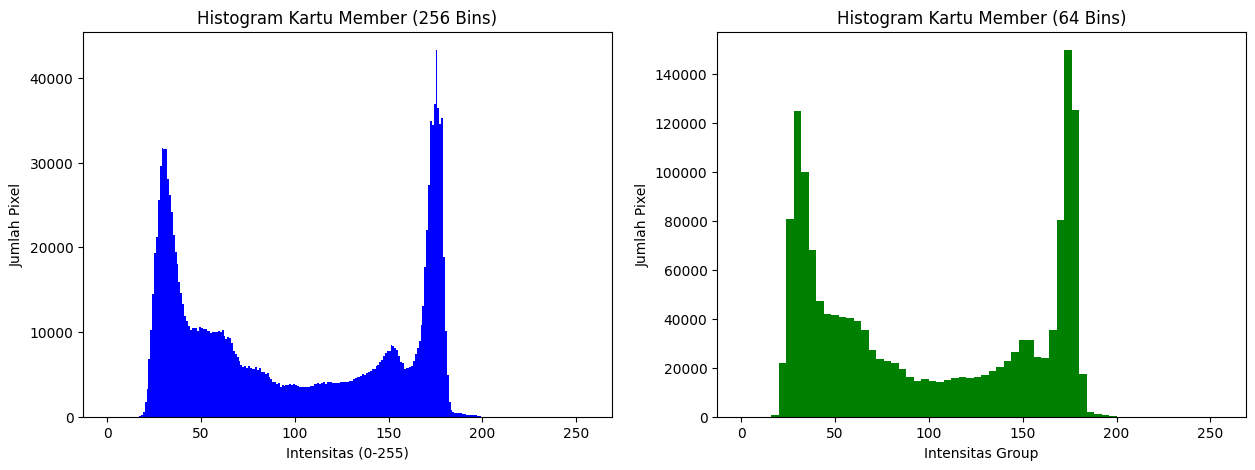

In [10]:
import cv2 as cv
import matplotlib.pyplot as plt


path_member = '/content/drive/MyDrive/PCVK/GAMBAR/foto_cahayaruangan.jfif'
img_member = cv.imread(path_member, cv.IMREAD_GRAYSCALE)


param_bins = 64

fig, axs = plt.subplots(1, 2, figsize=(15, 5))


axs[0].hist(img_member.flatten(), 256, [0,256], color='blue')
axs[0].set_title('Histogram Kartu Member (256 Bins)')
axs[0].set_xlabel('Intensitas (0-255)')
axs[0].set_ylabel('Jumlah Pixel')


axs[1].hist(img_member.flatten(), param_bins, [0,256], color='green')
axs[1].set_title(f"Histogram Kartu Member ({param_bins} Bins)")
axs[1].set_xlabel('Intensitas Group')
axs[1].set_ylabel('Jumlah Pixel')


axs[0].hist(img_member.flatten(), 256, range=[0,256], color='blue')
axs[1].hist(img_member.flatten(), param_bins, range=[0,256], color='green')
plt.show()